# Superstore Sales & Profit Analysis

This project analyzes sales performance, profitability, and customer behavior using the Superstore dataset.
 The goal is to identify key revenue drivers, loss-making products, and sales trends.

Tools used:

Python

Pandas

Seaborn

Matplotlib



In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
palette = sns.color_palette("flare")

In [2]:
pip install openpyxl


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
xls = pd.ExcelFile(r"C:\Users\rajar\OneDrive\Desktop\Superstore Project\Superstore.xlsx")
xls.sheet_names

['Sheet1', 'Sheet2', 'Sheet3', 'Sample - Superstore']

## Data Loading and Exploration

In [3]:
df = pd.read_excel(
    r"C:\Users\rajar\OneDrive\Desktop\Superstore Project\Superstore.xlsx",
    sheet_name="Sample - Superstore"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Profit Margin column
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,0.1125


## Data Cleaning and Feature Engineering


In [5]:
df.shape

(9994, 23)

In [11]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Profit Margin column,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,0.1600,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,0.3000,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,0.4700,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,-0.4000,10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,0.1125,10


In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Profit Margin column'],
      dtype='str')

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month"] = df["Order Date"].dt.month

In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [23]:
df["Month"] = df["Order Date"].dt.month

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [12]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Sales Analysis

In [7]:
sales_by_region = df.groupby("Region")["Sales"].sum()
sales_by_region

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

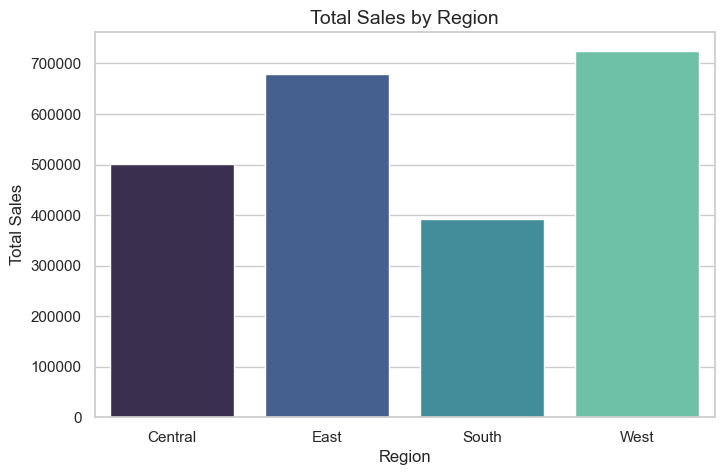

In [44]:
sales_region = df.groupby("Region")["Sales"].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x="Region",
    y="Sales",
    data=sales_region,
    hue="Region",
    palette="mako",
    legend=False
)

plt.title("Total Sales by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

In [20]:
sales_by_segment["Sales"] = sales_by_segment["Sales"].round(0)

sales_by_segment

,Segment,Sales
0,Consumer,1161401.0
1,Corporate,706146.0
2,Home Office,429653.0


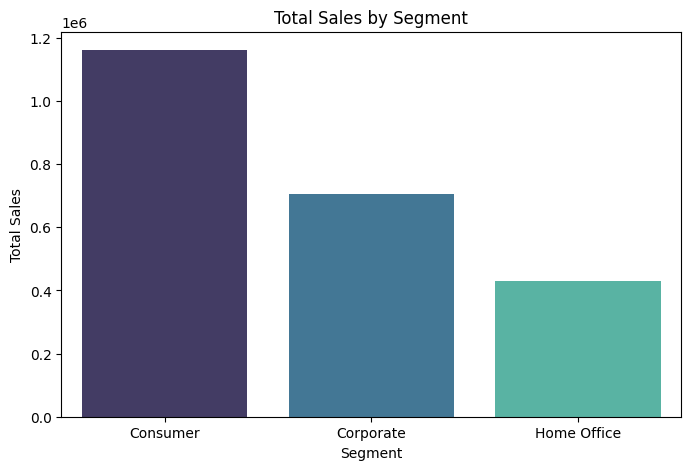

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Segment",
    y="Sales",
    data=sales_by_segment,
    hue="Segment",
    palette="mako",
    legend=False
)

plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.show()

In [32]:
pivot_table = df.pivot_table(values="Sales", index="Category", columns="Region", aggfunc="sum")
pivot_table

Region,Central,East,South,West
Category,,,,
Furniture,163797.1638,208291.204,117298.684,252612.7435
Office Supplies,167026.4150,205516.055,125651.313,220853.2490
Technology,170416.3120,264973.981,148771.908,251991.8320


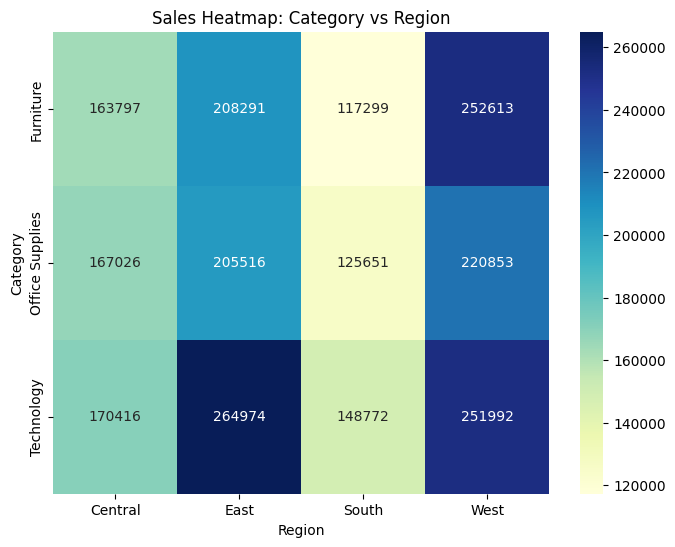

In [33]:
plt.figure(figsize=(8,6))

sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Sales Heatmap: Category vs Region")

plt.show()

## Profitability Analysis

In [14]:
profit_by_category = df.groupby("Category")["Profit"].sum().reset_index()

profit_by_category

,Category,Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


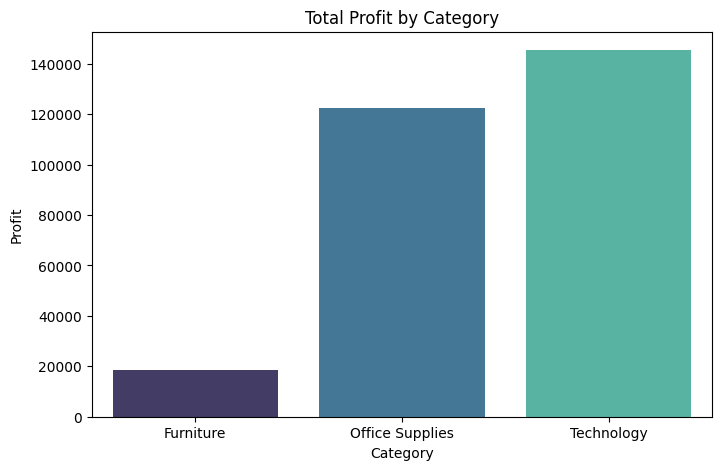

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Category",
    y="Profit",
    data=profit_by_category,
    hue="Category",
    palette="mako",
    legend=False
)

plt.title("Total Profit by Category")
plt.show()

In [24]:
profit_subcat = df.groupby("Sub-Category")["Profit"].sum().reset_index()

profit_subcat = profit_subcat.sort_values(by="Profit", ascending=False)

profit_subcat

,Sub-Category,Profit
6,Copiers,55617.8249
13,Phones,44515.7306
0,Accessories,41936.6357
12,Paper,34053.5693
3,Binders,30221.7633
5,Chairs,26590.1663
14,Storage,21278.8264
1,Appliances,18138.0054
9,Furnishings,13059.1436
7,Envelopes,6964.1767


C:\Users\rajar\AppData\Local\Temp\ipykernel_16252\553293569.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


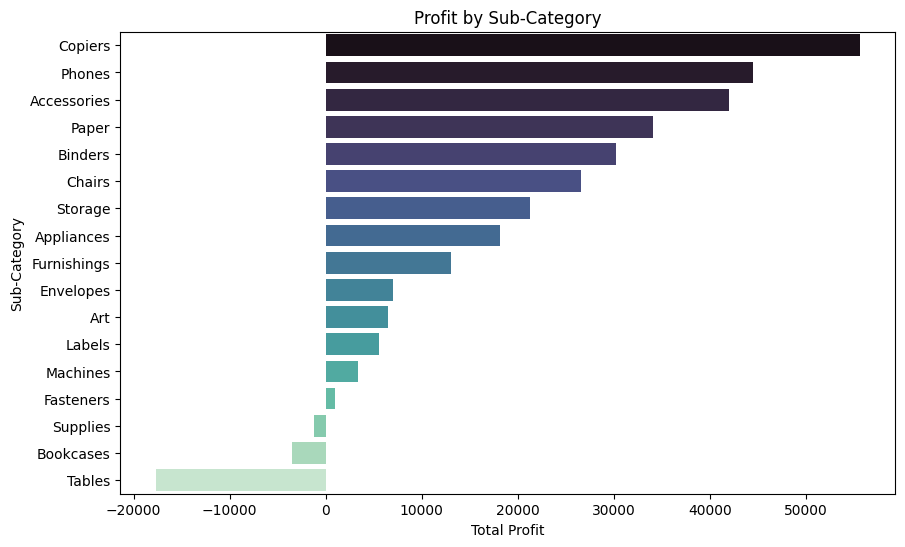

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Profit",
    y="Sub-Category",
    data=profit_subcat,
    palette="mako"
)

plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.show()

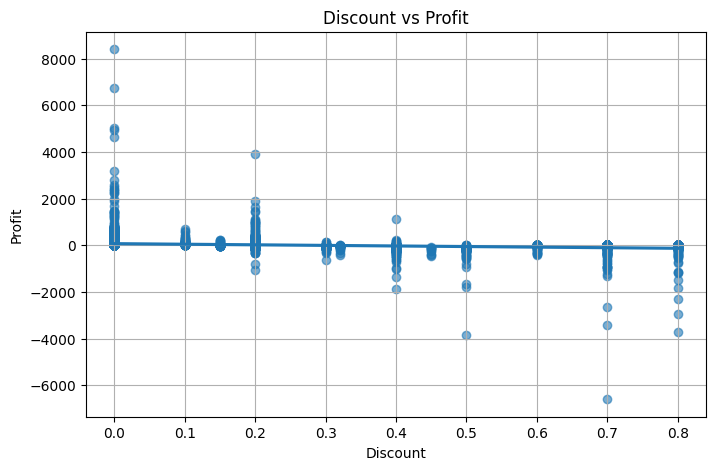

In [29]:
plt.figure(figsize=(8,5))

sns.regplot(
    x="Discount",
    y="Profit",
    data=df,
    scatter_kws={"alpha":0.6}
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

## Product Analysis

In [22]:
top_products = df.groupby("Product Name")["Sales"].sum().reset_index()

top_products = top_products.sort_values(by="Sales", ascending=False).head(10)

top_products

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


C:\Users\rajar\AppData\Local\Temp\ipykernel_16252\2780897531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


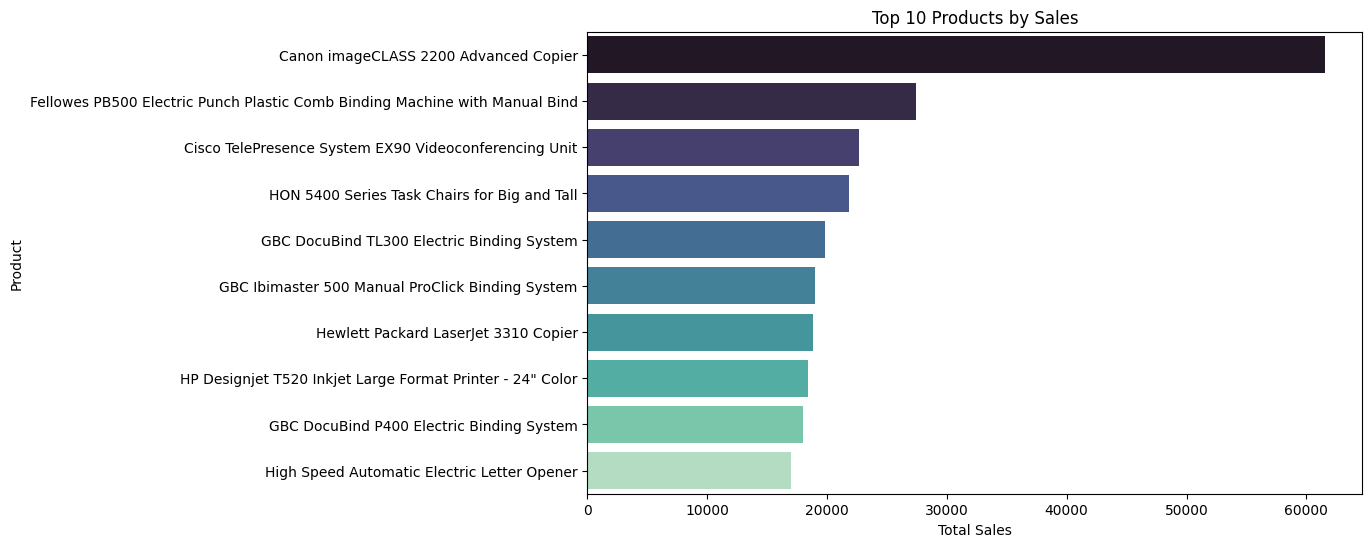

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Sales",
    y="Product Name",
    data=top_products,
    palette="mako"
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

## Sales Trend Analysis

In [16]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

monthly_sales

,Month,Sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


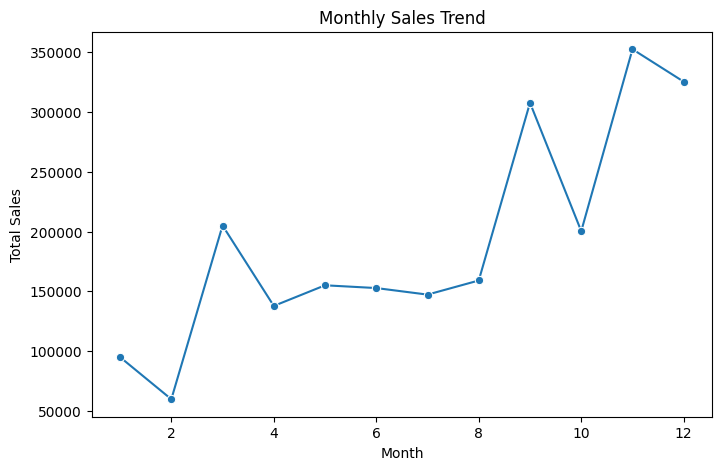

In [17]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x="Month",
    y="Sales",
    data=monthly_sales,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

## Conclusion

Key insights from the analysis:

• West region generates the highest sales.

• Consumer segment contributes the largest share of revenue.

• Technology category produces the highest profit.

• Tables sub-category generates significant losses.

• High discount levels lead to negative profit.

• Sales increase toward the end of the year with a peak in November.

These insights suggest that optimizing discount strategies and reviewing loss-making product categories could improve overall profitability.
